# K-Means

## Pipline 


Data gốc (46D): đã sclae+encodeing từ bước trước
        ↓
[Clustering]
- KMeans thường

[Giảm chiều]
PCA (với dữ liệu liên tục) sau đó ghép với biến rời rạc  / UMAP (≈15D)
        ↓
[Clustering]
- Kmmean thường + giảm chieuf 
- KMeans thường+ giảm chiều + thay đổi khoảng cách phù hợ với bộ dữ liệu 
- KMeans Constrained

-> áp dụng pca, umap cho cả 2 phương pháp, dùng pca thì visualization bằng pca và ngược lại 

ở các phương pháp đều: 
Đánh giá:
- Silhouette
- Davies-Bouldin
- Calinski-Harabasz
- Phân bố kích thước cụm
        ↓
Phân tích quan hệ giữa:
- đặc trưng đầu vào
- charges/output
trong từng cụm

visualizate cho hết vào 1-3 cái khung tùy kích thước,đảm bảo có biểu đồ (phân phối kích thước cụm, phân phối charges theo từng cụm,  heatmap theo từng cluster)
        ↓
[Chuyển sang Classification]
Cách 1:
Dùng nhãn từ KMeans Constrained

Cách 2:
Tạo score từ clustering
(distance / charges / risk score)
→ pd.qcut chia 3 lớp gần đều
        ↓
[Classification]
- Gaussian Naive Bayes
- Logistic Regression / Random Forest
        ↓
So sánh:
- dữ liệu gốc
- dữ liệu giảm chiều

## 1. Import thư viện và cấu hình chung

In [2]:

# ============================================================
# THƯ VIỆN
# ============================================================

# Cơ bản
import numpy as np
import pandas as pd
import math
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import umap

# Clustering
from sklearn.cluster import KMeans
from k_means_constrained import KMeansConstrained

# Clustering metrics
from sklearn.metrics import (
    silhouette_score, silhouette_samples, 
    davies_bouldin_score,
    calinski_harabasz_score,
)

# Classification
from sklearn.naive_bayes import GaussianNB

# Classification metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    adjusted_rand_score,
    fowlkes_mallows_score,
)

# Display
from IPython.display import display, Markdown

# Màu sắc cho các cụm
COLORS = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6',
          '#1ABC9C', '#E67E22', '#34495E', '#E91E63', '#00BCD4']


RANDOM_STATE = 42
TARGET_COL = "charges"
DATA_PATH = "data/support2_final.csv"



## 2. Đọc dữ liệu và tách input/output

In [3]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Missing values:', df.isnull().sum().sum())
# df.head()

# print(df.dtypes)
# print("\n---")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values | sample: {df[col].unique()[:5]}")
    
X = df.drop(columns = [TARGET_COL]).copy()
y = df[TARGET_COL].copy()

feature_names = X.columns.tolist()


Shape: (8933, 47)
Missing values: 0
age: 85 unique values | sample: [ 0.01931442 -0.17324779 -0.62255962 -1.32862106  1.11050029]
sex: 2 unique values | sample: [0 1]
num.co: 10 unique values | sample: [-1.39331441  0.09256604 -0.65037418  0.83550627  1.5784465 ]
edu: 31 unique values | sample: [-2.38759379e-01  8.18340875e-02  5.69488397e-16  7.23021020e-01
  1.36420795e+00]
income: 4 unique values | sample: [1 0 2 3]
scoma: 11 unique values | sample: [-0.48688655  1.30736923  0.5733555   1.75593317  1.02191944]
charges: 8501 unique values | sample: [ 9.18152929 10.44862764 10.62364174  8.03138533 10.82233501]
avtisst: 353 unique values | sample: [-1.18087715  0.4915256  -0.72476731 -0.29399771 -1.33291377]
sps: 600 unique values | sample: [ 0.93244586  2.11293293 -0.39462956 -0.44638497 -0.03677092]
aps: 124 unique values | sample: [-0.83553434  1.44870793  0.57150884 -0.92308466 -0.13666877]
hday: 84 unique values | sample: [-0.3709122  -0.15054316 -0.04035864 15.82621201  0.9513020

### Dữ liệu đầu vào 

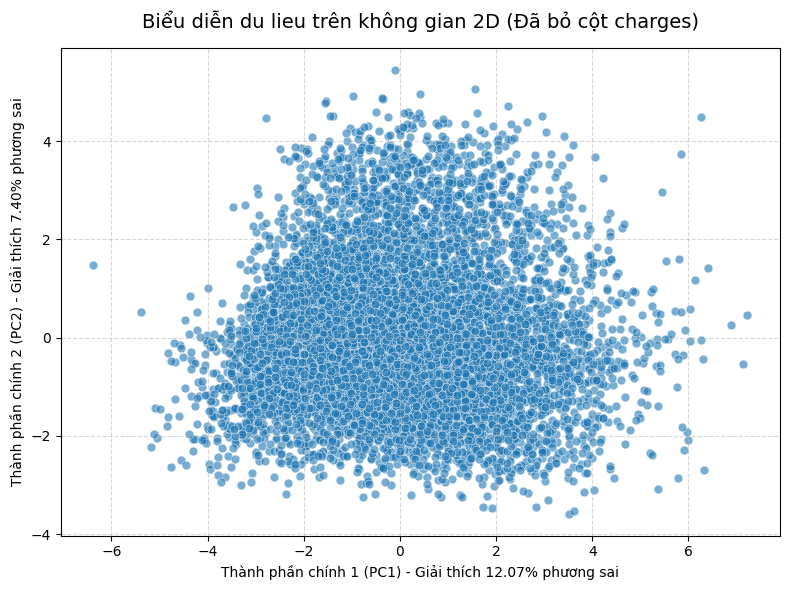

In [4]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)
plt.figure(figsize = (8,6))

sns.scatterplot(
    x = X_pca[:, 0], 
    y = X_pca[:, 1],
    palette = 'viridis',
    alpha = 0.6,
    s=40
)

plt.title(f'Biểu diễn du lieu trên không gian 2D (Đã bỏ cột charges)', fontsize=14, pad=15)
plt.xlabel(f'Thành phần chính 1 (PC1) - Giải thích {pca.explained_variance_ratio_[0]:.2%} phương sai')
plt.ylabel(f'Thành phần chính 2 (PC2) - Giải thích {pca.explained_variance_ratio_[1]:.2%} phương sai')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()



## 3. Tách biến liên tục và biến rời rạc/binary

In [5]:
def infer_discrete_continuous_cols(X_df, max_unique_for_discrete=5):
    discrete_cols = []
    continuous_cols = []

    for col in X_df.columns:
        values = X_df[col].dropna().unique()
        unique_count = len(values)
        is_binary = set(np.round(values, 8)).issubset({0, 1})

        if is_binary or unique_count <= max_unique_for_discrete:
            discrete_cols.append(col)
        else:
            continuous_cols.append(col)

    return continuous_cols, discrete_cols

continuous_cols, discrete_cols = infer_discrete_continuous_cols(X)

X_cont = X[continuous_cols].copy()
X_disc = X[discrete_cols].copy()

assert X_cont.shape[1] + X_disc.shape[1] == X.shape[1]
print(f"Biến liên tục : {X_cont.shape[1]} cột")
print(f"Biến rời rạc  : {X_disc.shape[1]} cột")
print(f"Tổng          : {X.shape[1]} cột")

Biến liên tục : 25 cột
Biến rời rạc  : 21 cột
Tổng          : 46 cột


## 4. Hàm chung

In [6]:
# Đánh giá mẫu dữ liệu đầu vào: 
def evaluate_internal(X, labels, model_name='KMeans'):
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    print(f"\n{'='*50}")
    print(f"  Internal Metrics — {model_name}")
    print(f"{'='*50}")
    print(f"  Silhouette Score    : {sil:+.4f}  ")
    print(f"  Davies-Bouldin Index: {db:.4f}   ")
    print(f"  Calinski-Harabasz   : {ch:.1f} ")
    print(f"{'='*50}\n")

    return {'model': model_name, 'silhouette': sil,
            'davies_bouldin': db, 'calinski_harabasz': ch}

# Đánh giá quan hệ giữa các dầu ra
def evaluate_external(df, labels, target_col='charges', n_bins=3, model_name='KMeans'):
    df = df.copy()
    df['_cluster'] = labels

    # Rời rạc hóa charges thành n_bins mức đều nhau (theo quantile)
    bin_labels = ['Thấp', 'Trung bình', 'Cao'][:n_bins]
    df['_target_bin'] = pd.qcut(df[target_col], q=n_bins, labels=bin_labels)

    ari = adjusted_rand_score(df['_target_bin'], labels)
    fmi = fowlkes_mallows_score(df['_target_bin'], labels)

    # Trung bình charges theo từng cụm
    mean_charges = df.groupby('_cluster')[target_col].mean().sort_values()

    print(f"\n{'='*50}")
    print(f"  External Metrics — {model_name} vs '{target_col}'")
    print(f"{'='*50}")
    print(f"  ARI (Adjusted Rand Index)  : {ari:+.4f}  (>0 = tốt hơn ngẫu nhiên)")
    print(f"  FMI (Fowlkes-Mallows Index): {fmi:.4f}   (0→1, cao hơn tốt hơn)")
    print(f"\n  Trung bình '{target_col}' theo cụm:")
    for cid, val in mean_charges.items():
        print(f"    Cluster {cid}: {val:.4f}")
    print(f"\n  Crosstab cụm × mức {target_col}:")
    print(pd.crosstab(df['_cluster'], df['_target_bin'], margins=True))
    print(f"{'='*50}\n")

    return {'model': model_name, 'ari': ari, 'fmi': fmi,
            'mean_target_per_cluster': mean_charges.to_dict()}


# pca_plot 
def plot_clusters_pca(X, labels, km_model=None,
                      title='K-Means', ax=None):
    
    k = len(np.unique(labels))
    pca = PCA(n_components=2, random_state=42)
    X2  = pca.fit_transform(X)
    var = pca.explained_variance_ratio_

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))

    for c in range(k):
        mask = labels == c
        ax.scatter(X2[mask, 0], X2[mask, 1],
                   c=COLORS[c], alpha=0.45, s=12, label=f'Cluster {c}')

    if km_model is not None and hasattr(km_model, 'cluster_centers_'):
        centroids_2d = pca.transform(km_model.cluster_centers_)
        ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                   c='black', marker='X', s=200, zorder=5, label='Centroid')

    ax.set_title(f'{title} – PCA 2D\n'
                 f'(PC1={var[0]:.1%}, PC2={var[1]:.1%})',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(True, alpha=0.2)

    if standalone:
        plt.tight_layout()
        plt.show()

# umap_plot 
def plot_clusters_umap(X, labels, km_model=None,
                       title='K-Means', ax=None):
    
    k = len(np.unique(labels))
    reducer = umap.UMAP(n_components=2, random_state=42)
    X2 = reducer.fit_transform(X)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))

    for c in range(k):
        mask = labels == c
        ax.scatter(X2[mask, 0], X2[mask, 1],
                   c=COLORS[c], alpha=0.45, s=12, label=f'Cluster {c}')

    if km_model is not None and hasattr(km_model, 'cluster_centers_'):
        centroids_2d = reducer.transform(km_model.cluster_centers_)
        ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                   c='black', marker='X', s=200, zorder=5, label='Centroid')

    ax.set_title(f'{title} – UMAP 2D', fontweight='bold', fontsize=10)
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(True, alpha=0.2)

    if standalone:
        plt.tight_layout()
        plt.show()


# Phân phối kích thước cụm
def plot_cluster_distribution(labels, title='KMeans', ax=None):
    """Pie chart thể hiện tỉ lệ mẫu trong từng cụm."""
    k = len(np.unique(labels))
    sizes = [np.sum(labels == c) for c in range(k)]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.pie(sizes,
           labels=[f'Cluster {c}\n({s:,})' for c, s in enumerate(sizes)],
           colors=COLORS[:k],
           autopct='%1.1f%%',
           startangle=140,
           wedgeprops=dict(edgecolor='white', linewidth=1.5))
    ax.set_title(f'Phân phối kích thước cụm — {title}', fontweight='bold')

    if standalone:
        plt.tight_layout()
        plt.show()


# HEATMAP ĐẶC TRƯNG THEO CỤM
def plot_feature_heatmap(df, labels, feature_names,
                         top_n=20, title='KMeans', ax=None):
    k = len(np.unique(labels))
    df = df.copy()
    df['_cluster'] = labels

    feats = [f for f in feature_names if f in df.columns]
    cluster_means = np.array([
        df[df['_cluster'] == c][feats].mean().values for c in range(k)
    ])
    feat_std = cluster_means.std(axis=0)
    top_idx  = np.argsort(feat_std)[::-1][:top_n]
    top_feats = [feats[i] for i in top_idx]
    data = cluster_means[:, top_idx]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(max(14, top_n * 0.7), 3 + k))

    im = ax.imshow(data, aspect='auto', cmap='RdYlGn',
                   vmin=-1.5, vmax=1.5)
    ax.set_xticks(range(len(top_feats)))
    ax.set_xticklabels(top_feats, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(k))
    ax.set_yticklabels([f'Cluster {c} (n={np.sum(labels==c):,})'
                        for c in range(k)], fontsize=10)
    ax.set_title(f'Heatmap — Top {top_n} đặc trưng phân biệt — {title}',
                 fontweight='bold')

    for i in range(k):
        for j in range(len(top_feats)):
            ax.text(j, i, f'{data[i, j]:.2f}',
                    ha='center', va='center', fontsize=6, color='black')

    if standalone:
        plt.colorbar(im, ax=ax, label='Giá trị chuẩn hóa')
        plt.tight_layout()
        plt.show()
    else:
        plt.colorbar(im, ax=ax, label='Giá trị chuẩn hóa')



def full_cluster_report(
    X,
    df,
    labels,
    km_model=None,
    feature_names=None,
    df_for_heatmap=None,
    target_col='charges',
    model_name='KMeans',
    use_umap=False,
    top_n_features=20
):
    """
    X              : dữ liệu dùng để phân cụm / tính metric
    df             : DataFrame gốc có chứa target_col, ví dụ charges
    labels         : nhãn cụm
    km_model       : mô hình phân cụm
    feature_names  : tên feature gốc dùng để vẽ heatmap
    df_for_heatmap : DataFrame feature gốc sau tiền xử lý, thường là X gốc
    target_col     : biến đầu ra để đánh giá, ví dụ charges
    model_name     : tên mô hình
    use_umap       : True nếu muốn vẽ scatter bằng UMAP
    top_n_features : số feature hiển thị trên heatmap
    """

    # Nếu không truyền df_for_heatmap thì dùng df
    if df_for_heatmap is None:
        df_for_heatmap = df.copy()

    # Nếu chưa truyền feature_names thì lấy từ df_for_heatmap
    if feature_names is None:
        feature_names = df_for_heatmap.columns.tolist()

    # Nếu feature_names là Index thì đổi sang list
    feature_names = list(feature_names)

    # Đánh giá metric
    internal = evaluate_internal(X, labels, model_name)
    external = evaluate_external(df, labels, target_col, model_name=model_name)

    # Tạo figure 2x3
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(f'Cluster Report — {model_name}', fontsize=15, fontweight='bold')

    # ========================================================
    # [0,0] Scatter PCA hoặc UMAP
    # ========================================================
    if use_umap:
        plot_clusters_umap(X, labels, km_model, title=model_name, ax=axes[0, 0])
    else:
        plot_clusters_pca(X, labels, km_model, title=model_name, ax=axes[0, 0])

    # ========================================================
    # [0,1] Phân phối kích thước cụm
    # ========================================================
    plot_cluster_distribution(labels, model_name, ax=axes[0, 1])

    # ========================================================
    # [0,2] Mean charges theo cụm
    # ========================================================
    df_tmp = df.copy()
    df_tmp['_cluster'] = labels

    mean_charges = df_tmp.groupby('_cluster')[target_col].mean()
    x_pos = np.arange(len(mean_charges))

    axes[0, 2].bar(
        x_pos,
        mean_charges.values,
        color=[COLORS[c] for c in mean_charges.index],
        edgecolor='white',
        linewidth=1.5
    )

    axes[0, 2].set_xticks(x_pos)
    axes[0, 2].set_xticklabels([f'Cluster {c}' for c in mean_charges.index])

    for i, (c, val) in enumerate(zip(mean_charges.index, mean_charges.values)):
        axes[0, 2].text(
            i,
            val + mean_charges.max() * 0.01,
            f'{val:.3f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    axes[0, 2].set_title(f'Mean {target_col} theo cụm — {model_name}', fontweight='bold')
    axes[0, 2].set_ylabel(f'Mean {target_col}')
    axes[0, 2].grid(True, axis='y', alpha=0.3)

    # ========================================================
    # [1,0] Boxplot charges theo cụm
    # ========================================================
    clusters = sorted(np.unique(labels))

    axes[1, 0].boxplot(
        [df_tmp[df_tmp['_cluster'] == c][target_col].values for c in clusters],
        labels=[f'Cluster {c}' for c in clusters],
        patch_artist=True,
        boxprops=dict(facecolor='#f0f0f0'),
        medianprops=dict(color='red', linewidth=2)
    )

    for c in clusters:
        vals = df_tmp[df_tmp['_cluster'] == c][target_col].values
        axes[1, 0].scatter(
            np.full(len(vals), c + 1) + np.random.uniform(-0.15, 0.15, len(vals)),
            vals,
            alpha=0.15,
            s=6,
            color=COLORS[c]
        )

    axes[1, 0].set_title(f'Phân phối {target_col} theo cụm — {model_name}', fontweight='bold')
    axes[1, 0].set_xlabel('Cluster')
    axes[1, 0].set_ylabel(target_col)
    axes[1, 0].grid(True, axis='y', alpha=0.3)

    # ========================================================
    # [1,1] Heatmap đặc trưng theo cụm
    # ========================================================
    plot_feature_heatmap(
        df=df_for_heatmap,
        labels=labels,
        feature_names=feature_names,
        top_n=top_n_features,
        title=model_name,
        ax=axes[1, 1]
    )

    # ========================================================
    # [1,2] Bảng metric tóm tắt
    # ========================================================
    axes[1, 2].axis('off')

    metric_text = (
        f"Internal Metrics\n"
        f"Silhouette: {internal['silhouette']:.4f}\n"
        f"Davies-Bouldin: {internal['davies_bouldin']:.4f}\n"
        f"Calinski-Harabasz: {internal['calinski_harabasz']:.1f}\n\n"
        f"External Metrics vs {target_col}\n"
        f"ARI: {external['ari']:.4f}\n"
        f"FMI: {external['fmi']:.4f}"
    )

    axes[1, 2].text(
        0.05,
        0.75,
        metric_text,
        fontsize=13,
        va='top',
        family='monospace',
        bbox=dict(boxstyle='round', facecolor='#f7f7f7', edgecolor='#cccccc')
    )

    axes[1, 2].set_title('Tóm tắt chỉ số đánh giá', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return {
        **internal,
        **{f'ext_{k}': v for k, v in external.items()}
    }


## 5. K_Means trên dữ liệu chưa giảm chiều

In [7]:
results = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    results.append({
        'k': k,
        'Silhouette': round(silhouette_score(X, labels), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X, labels), 4),
        'Calinski-Harabasz': round(calinski_harabasz_score(X, labels), 1),
    })

df_results = pd.DataFrame(results).set_index('k')
print("=== KMeans (Không giảm chiều)")
display(df_results)

=== KMeans (Không giảm chiều)


,Silhouette,Davies-Bouldin,Calinski-Harabasz
k,,,
2,0.0969,3.2833,776.2
3,0.0873,2.9884,622.2
4,0.0834,2.8777,536.8
5,0.0446,2.8651,487.4
6,0.0535,2.8661,444.2
7,0.0468,2.9053,411.8


## 6. Giảm chiều

In [8]:
# PCA: chỉ áp dụng cho biến liên tục, ghép lại biến rời rạc
pca = PCA(n_components=0.70, random_state=42)
X_cont_pca = pca.fit_transform(X_cont)
X_pca_reduced = np.hstack([X_cont_pca, X_disc.values])
pca_col_names = ([f'PC{i+1}' for i in range(X_cont_pca.shape[1])] + list(X_disc.columns))
X_pca_reduced = pd.DataFrame(X_pca_reduced, columns=pca_col_names, index=X.index)
print(f"PCA: {X_cont.shape[1]}D → {X_cont_pca.shape[1]}D + {X_disc.shape[1]}D rời rạc "
      f"= {X_pca_reduced.shape[1]}D | variance: {pca.explained_variance_ratio_.sum():.2%}")

# UMAP: áp dụng toàn bộ
reducer = umap.UMAP(n_components=15, random_state=42)
X_umap_arr = reducer.fit_transform(X)
umap_col_names = [f'UMAP{i+1}' for i in range(X_umap_arr.shape[1])]
X_umap_reduced = pd.DataFrame(X_umap_arr, columns=umap_col_names, index=X.index)
print(f"UMAP: {X.shape[1]}D → {X_umap_reduced.shape[1]}D")

PCA: 25D → 13D + 21D rời rạc = 34D | variance: 71.79%
UMAP: 46D → 15D


## 7. K-Means giảm chiều + các phương pháp khác

### K-Means + Giảm chiều

In [9]:
# ============================================================
# HÀM CHẠY K-MEANS + GIẢM CHIỀU
# ============================================================

def run_kmeans_reduced(
    X_reduced,
    df,
    X_original,
    k=3,
    dim_name="PCA",
    target_col="charges",
    random_state=42
):

    X_array = (
        X_reduced.values
        if hasattr(X_reduced, "values")
        else np.asarray(X_reduced)
    )

    feature_names = X_original.columns.tolist()

    kmeans_model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=random_state
    )

    labels = kmeans_model.fit_predict(X_array)

    metrics = full_cluster_report(
        X=X_array,
        df=df,
        labels=labels,
        km_model=kmeans_model,
        feature_names=feature_names,
        df_for_heatmap=X_original,
        target_col=target_col,
        model_name=f"KMeans + {dim_name}",
        use_umap=(dim_name.upper() == "UMAP")
    )

    metrics.update({
        "method": "KMeans",
        "dim_reduction": dim_name,
        "k": k
    })

    return labels, metrics, kmeans_model

### K-Means + Giảm chiều + Gower

In [10]:
def gower_distance_matrix(X, categorical_cols=None):
    """
    Tính ma trận khoảng cách Gower cho dữ liệu mixed.

    - Biến liên tục: chuẩn hóa min-max rồi tính khoảng cách tuyệt đối.
    - Biến categorical/rời rạc: khác nhau = 1, giống nhau = 0.

    X                : DataFrame hoặc numpy array
    categorical_cols : list tên cột categorical/rời rạc
    """

    if categorical_cols is None:
        categorical_cols = []

    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    X = X.copy()
    n = X.shape[0]

    categorical_cols = [c for c in categorical_cols if c in X.columns]
    numeric_cols = [c for c in X.columns if c not in categorical_cols]

    D = np.zeros((n, n), dtype=float)
    n_features = len(numeric_cols) + len(categorical_cols)

    if n_features == 0:
        raise ValueError("Không có feature nào để tính Gower distance.")

    # Biến liên tục
    for col in numeric_cols:
        values = X[col].astype(float).values
        min_val = np.nanmin(values)
        max_val = np.nanmax(values)
        range_val = max_val - min_val

        if range_val == 0:
            diff = np.zeros((n, n))
        else:
            values_scaled = (values - min_val) / range_val
            diff = np.abs(values_scaled[:, None] - values_scaled[None, :])

        D += diff

    # Biến categorical / rời rạc
    for col in categorical_cols:
        values = X[col].values
        diff = (values[:, None] != values[None, :]).astype(float)
        D += diff

    D = D / n_features

    return D

In [11]:
# ------------------------------------------------------------
# 2. K-Medoids với precomputed distance matrix
# ------------------------------------------------------------
def kmedoids_precomputed(D, k=3, max_iter=100, random_state=42):
    """
    Chạy K-Medoids từ ma trận khoảng cách đã tính sẵn.

    D : ma trận khoảng cách, shape = (n_samples, n_samples)
    k : số cụm

    Return:
    labels     : nhãn cụm
    medoid_idx : chỉ số medoid của từng cụm
    """

    rng = np.random.default_rng(random_state)
    n = D.shape[0]

    if D.shape[0] != D.shape[1]:
        raise ValueError("D phải là ma trận vuông.")

    if k > n:
        raise ValueError("k không được lớn hơn số mẫu.")

    # Khởi tạo medoid ngẫu nhiên
    medoid_idx = rng.choice(n, size=k, replace=False)

    for _ in range(max_iter):
        old_medoid_idx = medoid_idx.copy()

        # Gán mỗi điểm vào medoid gần nhất
        distances_to_medoids = D[:, medoid_idx]
        labels = np.argmin(distances_to_medoids, axis=1)

        # Cập nhật medoid từng cụm
        for cluster_id in range(k):
            cluster_points = np.where(labels == cluster_id)[0]

            if len(cluster_points) == 0:
                # Nếu cụm rỗng thì chọn lại random một điểm
                medoid_idx[cluster_id] = rng.integers(0, n)
                continue

            sub_D = D[np.ix_(cluster_points, cluster_points)]
            total_distances = sub_D.sum(axis=1)
            best_point = cluster_points[np.argmin(total_distances)]

            medoid_idx[cluster_id] = best_point

        # Điều kiện dừng
        if np.array_equal(old_medoid_idx, medoid_idx):
            break

    # Gán nhãn lần cuối
    labels = np.argmin(D[:, medoid_idx], axis=1)

    return labels, medoid_idx

In [12]:
# ------------------------------------------------------------
# 3. Classical MDS để embed distance matrix sang không gian vector
# ------------------------------------------------------------
def classical_mds(D, n_components=5):
    """
    Classical MDS từ distance matrix.

    D            : ma trận khoảng cách
    n_components : số chiều embedding đầu ra

    Return:
    X_embed : dữ liệu embedding, shape = (n_samples, n_components)
    """

    D = np.asarray(D)
    n = D.shape[0]

    # Double centering
    D_squared = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D_squared @ J

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(B)

    # Sắp xếp eigenvalue giảm dần
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Chỉ lấy eigenvalue dương
    positive_idx = eigvals > 0
    eigvals = eigvals[positive_idx]
    eigvecs = eigvecs[:, positive_idx]

    n_components = min(n_components, len(eigvals))

    X_embed = eigvecs[:, :n_components] * np.sqrt(eigvals[:n_components])

    return X_embed

In [13]:
# ------------------------------------------------------------
# 4. Dummy model để truyền vào full_cluster_report
# ------------------------------------------------------------
class DummyMedoidModel:
    """
    Model giả cho K-Medoids + Gower.

    Vì full_cluster_report có nhận km_model,
    nên class này giúp truyền medoid/embedding vào cho đồng bộ.
    """

    def __init__(self, labels=None, X_embed=None):
        self.labels_ = labels
        self.X_embed = X_embed

In [14]:
# ============================================================
# K-MEDOIDS + GOWER TRÊN DỮ LIỆU ĐÃ GIẢM CHIỀU
# ============================================================

def run_kmedoids_gower(
    X_cluster,
    df,
    X_original,
    k=3,
    dim_name="PCA",
    categorical_cols=None,
    target_col="charges",
    random_state=42,
    top_n_features=20
):
    """
    Chạy K-Medoids + Gower trên dữ liệu đã giảm chiều PCA/UMAP.

    X_cluster       : dữ liệu dùng để phân cụm, ví dụ X_pca_reduced hoặc X_umap_reduced
    df              : dataframe gốc có cột target_col
    X_original      : dữ liệu gốc sau tiền xử lý, dùng để vẽ heatmap
    k               : số cụm
    dim_name        : tên phương pháp giảm chiều, ví dụ "PCA" hoặc "UMAP"
    categorical_cols: danh sách cột rời rạc trong X_cluster
    target_col      : biến đầu ra, ví dụ charges
    """

    if categorical_cols is None:
        categorical_cols = []

    print(f"\n{'='*70}")
    print(f"K-Medoids + Gower | {dim_name}")
    print(f"{'='*70}")
    print(f"Shape dữ liệu phân cụm: {X_cluster.shape}")

    # 1. Tính ma trận khoảng cách Gower
    print("Đang tính Gower distance matrix...")
    D_gower = gower_distance_matrix(
        X_cluster,
        categorical_cols=categorical_cols
    )

    # 2. Chạy K-Medoids với distance matrix
    labels, medoid_idx = kmedoids_precomputed(
        D_gower,
        k=k,
        random_state=random_state
    )

    # 3. Silhouette đúng theo Gower
    sil_gower = silhouette_score(
        D_gower,
        labels,
        metric="precomputed"
    )

    print(f"Silhouette Gower: {sil_gower:.4f}")
    print(f"Medoid indices: {medoid_idx}")
    print("Phân phối cụm:")
    print(pd.Series(labels).value_counts().sort_index())

    # 4. Embed ma trận Gower bằng MDS để vẽ biểu đồ
    X_embed = classical_mds(
        D_gower,
        n_components=5
    )

    # 5. Model giả để truyền vào full_cluster_report
    gower_model = DummyMedoidModel(
        labels=labels,
        X_embed=X_embed
    )

    # 6. Feature gốc dùng để vẽ heatmap
    feature_names = X_original.columns.tolist()

    # 7. Đánh giá + vẽ dashboard
    metrics = full_cluster_report(
        X=X_embed,
        df=df,
        labels=labels,
        km_model=gower_model,
        feature_names=feature_names,
        df_for_heatmap=X_original,
        target_col=target_col,
        model_name=f"K-Medoids + Gower | {dim_name}",
        use_umap=False,
        top_n_features=top_n_features
    )

    # Ghi đè silhouette bằng silhouette tính trên Gower distance
    metrics["silhouette"] = sil_gower

    metrics.update({
        "method": "K-Medoids + Gower",
        "dim_reduction": dim_name,
        "k": k
    })

    return labels, metrics, gower_model, D_gower, X_embed, medoid_idx

### K-Means Constrained

In [15]:
# ============================================================
# KMEANS CONSTRAINED TRÊN DỮ LIỆU ĐÃ GIẢM CHIỀU
# ============================================================

def run_kmeans_constrained(
    X_cluster,
    df,
    X_original,
    k=3,
    dim_name="PCA",
    tolerance=0.05,
    target_col="charges",
    random_state=42,
    top_n_features=20
):
    """
    Chạy KMeans Constrained trên dữ liệu đã giảm chiều PCA/UMAP
    và đánh giá bằng full_cluster_report.

    X_cluster      : dữ liệu dùng để phân cụm, ví dụ X_pca_reduced hoặc X_umap_reduced
    df             : DataFrame gốc có chứa target_col, ví dụ charges
    X_original     : dữ liệu gốc sau tiền xử lý, dùng để vẽ heatmap
    k              : số cụm
    dim_name       : tên phương pháp giảm chiều, ví dụ "PCA" hoặc "UMAP"
    tolerance      : mức cho phép lệch kích thước cụm, ví dụ 0.05 = 5%
    target_col     : biến đầu ra để đánh giá external
    random_state   : seed
    top_n_features : số feature hiển thị trên heatmap
    """

    print(f"\n{'='*70}")
    print(f"KMeans Constrained | {dim_name}")
    print(f"{'='*70}")
    print(f"Shape dữ liệu phân cụm: {X_cluster.shape}")

    # Chuyển dữ liệu về numpy array
    X_array = (
        X_cluster.values
        if hasattr(X_cluster, "values")
        else np.asarray(X_cluster)
    )

    # Tính size_min, size_max để ép cụm gần đều
    n_samples = X_array.shape[0]
    base = n_samples // k

    size_min = int(base * (1 - tolerance))
    size_max = math.ceil(base * (1 + tolerance))

    print(f"Số mẫu: {n_samples}")
    print(f"Số cụm k: {k}")
    print(f"Size trung bình mỗi cụm: {base}")
    print(f"size_min={size_min} | size_max={size_max}")

    # Khởi tạo KMeans Constrained
    kcc_model = KMeansConstrained(
        n_clusters=k,
        size_min=size_min,
        size_max=size_max,
        random_state=random_state
    )

    # Fit và lấy nhãn cụm
    labels = kcc_model.fit_predict(X_array)

    print("Phân phối cụm:")
    print(pd.Series(labels).value_counts().sort_index())

    # Feature gốc dùng để vẽ heatmap
    feature_names = X_original.columns.tolist()

    # Đánh giá + vẽ dashboard
    metrics = full_cluster_report(
        X=X_array,
        df=df,
        labels=labels,
        km_model=kcc_model,
        feature_names=feature_names,
        df_for_heatmap=X_original,
        target_col=target_col,
        model_name=f"KMeans Constrained | {dim_name}",
        use_umap=(dim_name.upper() == "UMAP"),
        top_n_features=top_n_features
    )

    metrics.update({
        "method": "KMeans Constrained",
        "dim_reduction": dim_name,
        "k": k,
        "size_min": size_min,
        "size_max": size_max,
        "tolerance": tolerance
    })

    return labels, metrics, kcc_model

### K-Prototypes trên dữ liệu PCA cont + discrete 

In [36]:
def evaluate_kprototypes_only(
    X_cluster,
    df,
    discrete_cols,
    k=3,
    target_col="charges",
    gamma=None,
    random_state=42,
    model_name="K-Prototypes"
):
    if not isinstance(X_cluster, pd.DataFrame):
        raise ValueError("X_cluster phải là DataFrame để xác định discrete_cols.")

    X_kproto = X_cluster.copy()

    discrete_cols = [c for c in discrete_cols if c in X_kproto.columns]
    numeric_cols = [c for c in X_kproto.columns if c not in discrete_cols]

    X_kproto[numeric_cols] = X_kproto[numeric_cols].astype(float)
    X_kproto[discrete_cols] = X_kproto[discrete_cols].astype(int)

    categorical_idx = [X_kproto.columns.get_loc(c) for c in discrete_cols]

    print(f"\n{'='*80}")
    print(f"{model_name}")
    print(f"{'='*80}")
    print(f"Shape dữ liệu: {X_kproto.shape}")
    print(f"Số biến numeric    : {len(numeric_cols)}")
    print(f"Số biến categorical: {len(discrete_cols)}")
    print(f"k = {k}")

    model = KPrototypes(
        n_clusters=k,
        init="Cao",
        n_init=5,
        gamma=gamma,
        random_state=random_state,
        verbose=0
    )

    labels = model.fit_predict(
        X_kproto.to_numpy(),
        categorical=categorical_idx
    )

    D_kproto = kprototypes_distance_matrix(
        X=X_kproto,
        numeric_cols=numeric_cols,
        categorical_cols=discrete_cols,
        gamma=model.gamma
    )

    sil_kproto = silhouette_score(
        D_kproto,
        labels,
        metric="precomputed"
    )

    df_eval = df.copy()
    df_eval["_cluster"] = labels

    bin_labels = ["Thấp", "Trung bình", "Cao"][:k]
    df_eval["_target_bin"] = pd.qcut(
        df_eval[target_col],
        q=k,
        labels=bin_labels
    )

    ari = adjusted_rand_score(df_eval["_target_bin"], labels)
    fmi = fowlkes_mallows_score(df_eval["_target_bin"], labels)

    cluster_size = pd.Series(labels).value_counts().sort_index()
    mean_target = df_eval.groupby("_cluster")[target_col].mean().sort_index()
    crosstab = pd.crosstab(df_eval["_cluster"], df_eval["_target_bin"], margins=True)

    print("\nPhân phối cụm:")
    print(cluster_size)

    print(f"\nCost: {model.cost_:.4f}")
    print(f"Gamma: {model.gamma}")

    print("\nChỉ số đánh giá:")
    print(f"Silhouette K-Prototypes distance : {sil_kproto:.4f}")
    print(f"ARI với {target_col}             : {ari:.4f}")
    print(f"FMI với {target_col}             : {fmi:.4f}")

    print(f"\nTrung bình {target_col} theo cụm:")
    print(mean_target)

    print(f"\nCrosstab cụm × mức {target_col}:")
    print(crosstab)

    print(f"{'='*80}\n")

    metrics = {
        "model": model_name,
        "method": "K-Prototypes",
        "k": k,
        "cost": model.cost_,
        "gamma": model.gamma,
        "silhouette_kproto": sil_kproto,
        "ari": ari,
        "fmi": fmi,
        "cluster_size": cluster_size.to_dict(),
        "mean_target_per_cluster": mean_target.to_dict()
    }

    return labels, metrics, model

In [37]:
kproto_ori_labels, kproto_ori_metrics, kproto_ori_model = evaluate_kprototypes_only(
    X_cluster=X,
    df=df,
    discrete_cols=list(X_disc.columns),
    k=3,
    target_col="charges",
    gamma=None,
    model_name="K-Prototypes | Original Data"
)


K-Prototypes | Original Data
Shape dữ liệu: (8933, 46)
Số biến numeric    : 25
Số biến categorical: 21
k = 3


NameError: name 'kprototypes_distance_matrix' is not defined

In [38]:
kproto_pca_labels, kproto_pca_metrics, kproto_pca_model = evaluate_kprototypes_only(
    X_cluster=X_pca_reduced,
    df=df,
    discrete_cols=list(X_disc.columns),
    k=3,
    target_col="charges",
    gamma=None,
    random_state=42,
    model_name="K-Prototypes | PCA Continuous + Discrete"
)


K-Prototypes | PCA Continuous + Discrete
Shape dữ liệu: (8933, 34)
Số biến numeric    : 13
Số biến categorical: 21
k = 3


NameError: name 'kprototypes_distance_matrix' is not defined

In [ ]:
# ============================================================
# K-PROTOTYPES TRÊN BỘ DỮ LIỆU GỐC, KHÔNG GIẢM CHIỀU
# ============================================================

from kmodes.kprototypes import KPrototypes

def run_kprototypes_original(
    X_original,
    df,
    discrete_cols,
    k=3,
    target_col="charges",
    gamma=None,
    random_state=42,
    top_n_features=20
):
    """
    Chạy K-Prototypes trực tiếp trên bộ dữ liệu gốc sau tiền xử lý.

    X_original    : DataFrame feature gốc sau tiền xử lý, ví dụ X
    df            : DataFrame gốc có chứa target_col, ví dụ charges
    discrete_cols : danh sách cột rời rạc/categorical trong X_original
    k             : số cụm
    gamma         : trọng số cân bằng numeric/categorical, None thì tự ước lượng
    """

    print(f"\n{'='*70}")
    print("K-Prototypes | Original Data")
    print(f"{'='*70}")
    print(f"Shape dữ liệu phân cụm: {X_original.shape}")

    if not isinstance(X_original, pd.DataFrame):
        raise ValueError("X_original phải là DataFrame để xác định cột categorical.")

    # Lọc cột rời rạc thật sự tồn tại trong X_original
    discrete_cols = [c for c in discrete_cols if c in X_original.columns]

    # Index của các cột categorical/rời rạc
    categorical_idx = [
        X_original.columns.get_loc(c)
        for c in discrete_cols
    ]

    print(f"Số cột categorical/rời rạc: {len(categorical_idx)}")
    print(f"Categorical indices: {categorical_idx}")

    # Copy dữ liệu để tránh sửa X gốc
    X_kproto = X_original.copy()

    # Các cột numeric là phần còn lại
    numeric_cols = [
        c for c in X_kproto.columns
        if c not in discrete_cols
    ]

    # Đảm bảo numeric là float
    X_kproto[numeric_cols] = X_kproto[numeric_cols].astype(float)

    # Đảm bảo categorical là dạng int/string
    # Nếu one-hot 0/1 thì giữ int là ổn
    X_kproto[discrete_cols] = X_kproto[discrete_cols].astype(int)

    X_array = X_kproto.to_numpy()

    kproto_model = KPrototypes(
        n_clusters=k,
        init="Cao",
        n_init=5,
        gamma=gamma,
        random_state=random_state,
        verbose=0
    )

    labels = kproto_model.fit_predict(
        X_array,
        categorical=categorical_idx
    )

    print("Phân phối cụm:")
    print(pd.Series(labels).value_counts().sort_index())
    print(f"Cost: {kproto_model.cost_:.4f}")
    print(f"Gamma: {kproto_model.gamma}")

    metrics = full_cluster_report(
        X=X_kproto.values,
        df=df,
        labels=labels,
        km_model=None,
        feature_names=X_original.columns.tolist(),
        df_for_heatmap=X_original,
        target_col=target_col,
        model_name="K-Prototypes | Original Data",
        use_umap=False,
        top_n_features=top_n_features
    )

    metrics.update({
        "method": "K-Prototypes",
        "dim_reduction": "None",
        "k": k,
        "cost": kproto_model.cost_,
        "gamma": kproto_model.gamma
    })

    return labels, metrics, kproto_model


K-Prototypes | Original Data
Shape dữ liệu phân cụm: (8933, 46)
Số cột categorical/rời rạc: 21
Categorical indices: [1, 4, 10, 11, 12, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]
Phân phối cụm:
0    4397
1    3161
2    1375
Name: count, dtype: int64
Cost: 207826.0951
Gamma: 0.49997201309784856

  Internal Metrics — K-Prototypes | Original Data
  Silhouette Score    : +0.0888  
  Davies-Bouldin Index: 2.9921   
  Calinski-Harabasz   : 619.8 


  External Metrics — K-Prototypes | Original Data vs 'charges'
  ARI (Adjusted Rand Index)  : +0.1735  (>0 = tốt hơn ngẫu nhiên)
  FMI (Fowlkes-Mallows Index): 0.4724   (0→1, cao hơn tốt hơn)

  Trung bình 'charges' theo cụm:
    Cluster 0: 9.5024
    Cluster 2: 10.2056
    Cluster 1: 11.0947

  Crosstab cụm × mức charges:
_target_bin  Thấp  Trung bình   Cao   All
_cluster                                 
0            2344        1503   550  4397
1             233         926  2002  3161
2             401         548   426  13

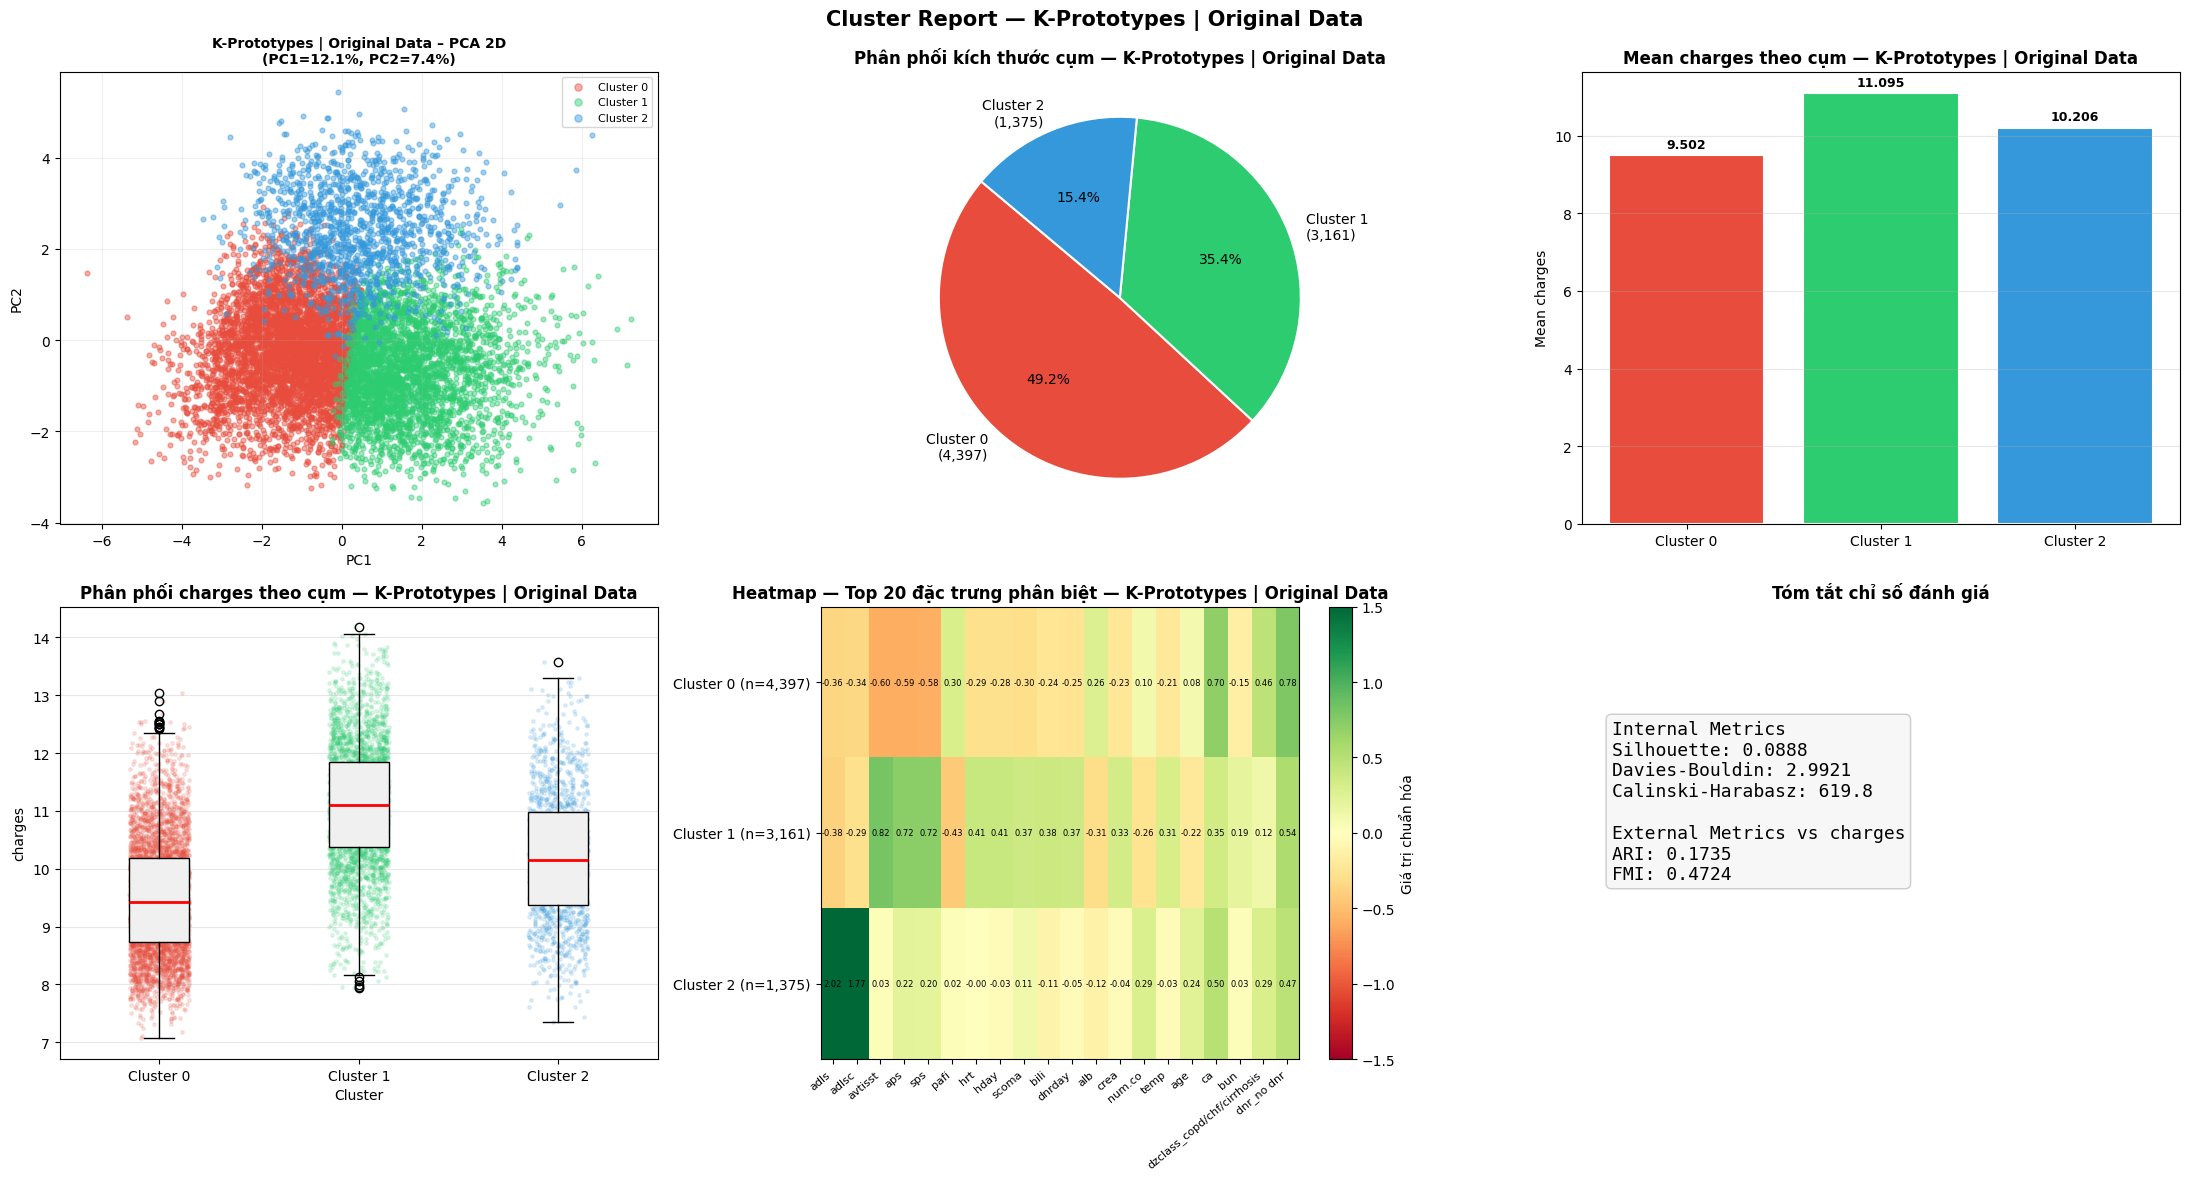

In [ ]:
kproto_original_labels, kproto_original_metrics, kproto_original_model = run_kprototypes_original(
    X_original=X,
    df=df,
    discrete_cols=list(X_disc.columns),
    k=3,
    target_col="charges",
    gamma=None
)

In [31]:
compare_kproto = pd.DataFrame([
    kproto_original_metrics,
    kproto_metrics   # cái này là bản K-Prototypes | PCA Mixed nếu mày đã chạy trước đó
])

compare_kproto[
    [
        "method",
        "dim_reduction",
        "k",
        "silhouette",
        "davies_bouldin",
        "calinski_harabasz",
        "ext_ari",
        "ext_fmi",
        "cost",
        "gamma"
    ]
]

,method,dim_reduction,k,silhouette,davies_bouldin,calinski_harabasz,ext_ari,ext_fmi,cost,gamma
0,K-Prototypes,None,3,0.088781,2.992108,619.784766,0.173481,0.472436,207826.095139,0.499972
1,K-Prototypes,PCA Mixed,3,0.114106,2.524154,857.922239,0.171343,0.470798,147124.260195,0.574997


In [ ]:
# ------------------------------------------------------------
# 4. Dummy model để truyền vào full_cluster_report
# ------------------------------------------------------------
class DummyMedoidModel:
    """
    Model giả cho K-Medoids + Gower.

    Vì full_cluster_report có nhận km_model,
    nên class này giúp truyền medoid/embedding vào cho đồng bộ.
    """

    def __init__(self, labels=None, X_embed=None):
        self.labels_ = labels
        self.X_embed = X_embed

## Phan loai 

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.decomposition import PCA as PCA_clf
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')


In [19]:
df_clf = pd.read_csv('data/support2_final.csv')

# Ngưỡng chia theo percentile 33/66 -> 3 khoảng ~2950 mẫu mỗi khoảng
BINS   = [df_clf['charges'].min() - 0.01, 9.50, 10.72,
          df_clf['charges'].max() + 0.01]
LABELS = ['Low', 'Medium', 'High']

df_clf['label'] = pd.cut(df_clf['charges'], bins=BINS, labels=LABELS)

print('=== Ngưỡng chia ===')
for i in range(len(LABELS)):
    print(f'  {LABELS[i]:10s}: ({BINS[i]:.2f}, {BINS[i+1]:.2f}]')
print()
print('=== Phân phối nhãn ===')
print(df_clf['label'].value_counts().sort_index())

X_clf = df_clf.drop(columns=['charges', 'label']).values
y_clf = df_clf['label'].values
feature_names_clf = df_clf.drop(columns=['charges', 'label']).columns.tolist()
print(f'\nX shape: {X_clf.shape}  |  n_classes: {len(LABELS)}')


=== Ngưỡng chia ===
  Low       : (7.05, 9.50]
  Medium    : (9.50, 10.72]
  High      : (10.72, 14.19]

=== Phân phối nhãn ===
label
Low       2952
Medium    2942
High      3039
Name: count, dtype: int64

X shape: (8933, 46)  |  n_classes: 3


### GIam chieu bang lda


In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

n_original = X_clf.shape[1]
# LDA giới hạn tối đa n_classes - 1 chiều
n_reduced = len(LABELS) - 1  # = 2
print(f'Số chiều gốc: {n_original}  ->  Số chiều sau LDA: {n_reduced}')

lda = LinearDiscriminantAnalysis(n_components=n_reduced)
X_clf_lda = lda.fit_transform(X_clf, y_clf)

var_explained = lda.explained_variance_ratio_.sum()
print(f'Tổng phương sai giữ lại: {var_explained:.2%}')

Số chiều gốc: 46  ->  Số chiều sau LDA: 2
Tổng phương sai giữ lại: 100.00%


In [21]:
SPLIT_RATIOS = [
    ('6:4', 0.4),
    ('7:3', 0.3),
    ('8:2', 0.2),
]


def split_data(X, y, test_size, random_state=42):
    """Chia train/test theo tỉ lệ cho trước."""
    return train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )


def evaluate(y_test, y_pred, model_name='', ratio_name=''):
    """In báo cáo và trả về dict kết quả."""
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test, y_pred, target_names=LABELS, output_dict=True
    )
    print(f'[{ratio_name}] {model_name}  |  Accuracy = {acc:.4f}')
    print(classification_report(y_test, y_pred, target_names=LABELS))
    return {'model': model_name, 'ratio': ratio_name,
            'accuracy': acc, 'report': report}


def plot_confusion(y_test, y_pred, model_name, ratio_name, ax):
    """Vẽ confusion matrix lên axes cho trước."""
    cm = confusion_matrix(y_test, y_pred, labels=LABELS)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} | {ratio_name}', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=30)


In [22]:
def run_naive_bayes(X, y, ratio_name):
    """Gaussian Naive Bayes – phù hợp với dữ liệu liên tục đã chuẩn hóa."""
    test_size = dict(SPLIT_RATIOS)[ratio_name]
    X_train, X_test, y_train, y_test = split_data(X, y, test_size)
    model = GaussianNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    result = evaluate(y_test, y_pred, 'Naive Bayes', ratio_name)
    return result, model, y_test, y_pred


def run_svm(X, y, ratio_name):
    """SVM với kernel RBF."""
    test_size = dict(SPLIT_RATIOS)[ratio_name]
    X_train, X_test, y_train, y_test = split_data(X, y, test_size)
    model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    result = evaluate(y_test, y_pred, 'SVM (RBF)', ratio_name)
    return result, model, y_test, y_pred


### du lieu goc 

In [23]:
print('=' * 60)
print('DU LIEU GOC  –  47 chieu')
print('=' * 60)

results_orig = []
preds_orig   = []

for ratio_name, _ in SPLIT_RATIOS:
    print(f'\n--- Train:Test = {ratio_name} ---')
    res_nb, _, yt_nb, yp_nb = run_naive_bayes(X_clf, y_clf, ratio_name)
    res_sv, _, yt_sv, yp_sv = run_svm(X_clf, y_clf, ratio_name)
    results_orig.extend([res_nb, res_sv])
    preds_orig.extend([
        (yt_nb, yp_nb, 'Naive Bayes', ratio_name),
        (yt_sv, yp_sv, 'SVM (RBF)',   ratio_name),
    ])


DU LIEU GOC  –  47 chieu

--- Train:Test = 6:4 ---
[6:4] Naive Bayes  |  Accuracy = 0.6301
              precision    recall  f1-score   support

         Low       0.62      0.88      0.72      1216
      Medium       0.68      0.84      0.75      1181
        High       0.49      0.16      0.24      1177

    accuracy                           0.63      3574
   macro avg       0.60      0.63      0.57      3574
weighted avg       0.60      0.63      0.57      3574

[6:4] SVM (RBF)  |  Accuracy = 0.7566
              precision    recall  f1-score   support

         Low       0.86      0.80      0.83      1216
      Medium       0.78      0.82      0.80      1181
        High       0.64      0.64      0.64      1177

    accuracy                           0.76      3574
   macro avg       0.76      0.76      0.76      3574
weighted avg       0.76      0.76      0.76      3574


--- Train:Test = 7:3 ---
[7:3] Naive Bayes  |  Accuracy = 0.6340
              precision    recall  f1-score

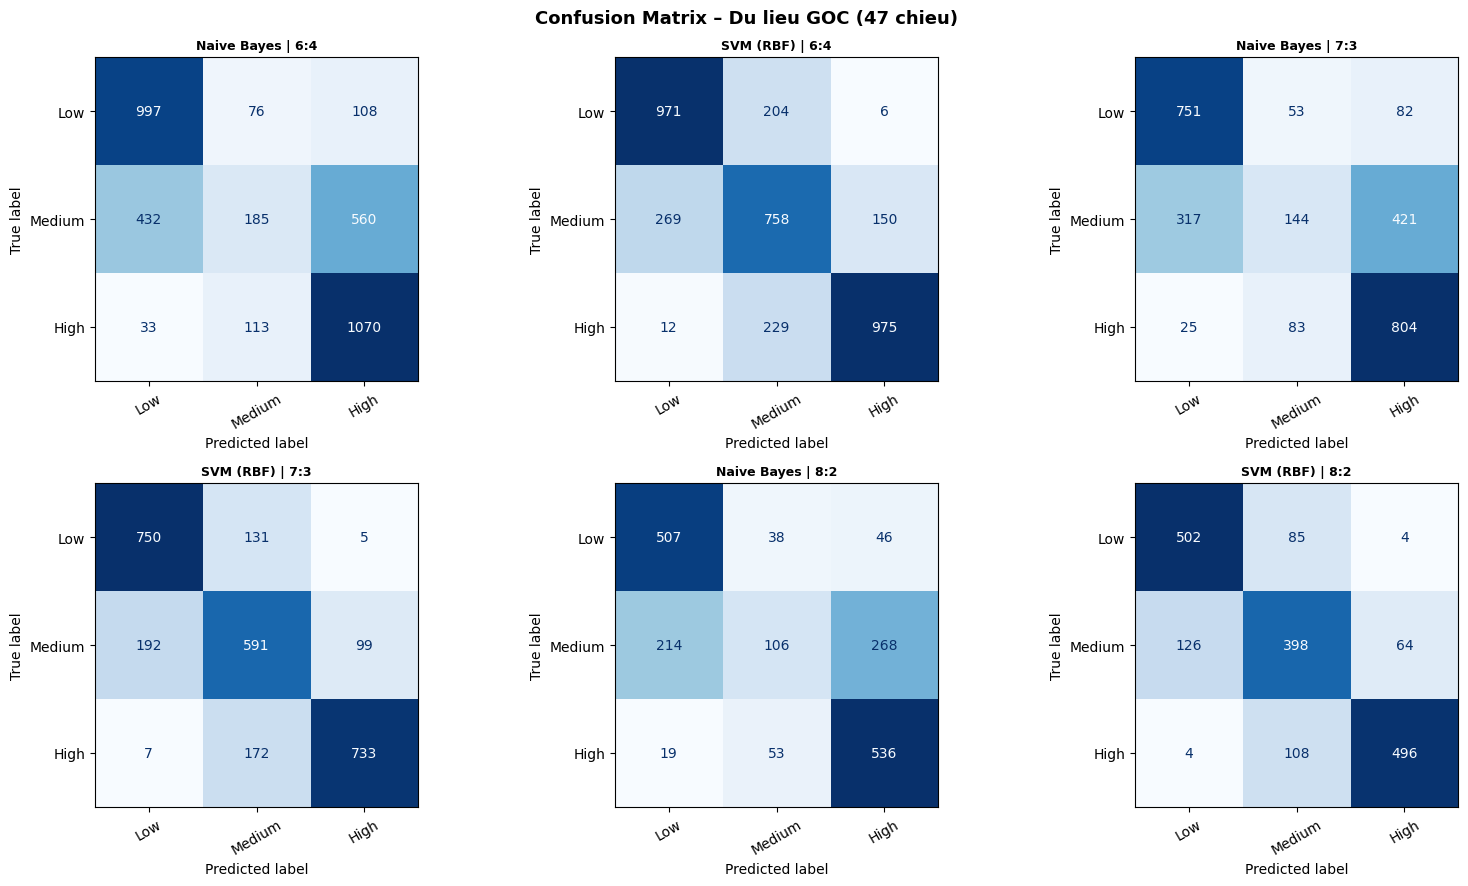

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Confusion Matrix – Du lieu GOC (47 chieu)', fontsize=13, fontweight='bold')

for idx, (yt, yp, mname, rname) in enumerate(preds_orig):
    row, col = divmod(idx, 3)
    plot_confusion(yt, yp, mname, rname, axes[row][col])

plt.tight_layout()
plt.show()


### du lieu da giam chieu lda 

In [25]:
print('=' * 60)
print(f'DU LIEU GIAM CHIEU  –  {n_reduced} chieu (LDA)')
print('=' * 60)

results_lda = []
preds_lda   = []

for ratio_name, _ in SPLIT_RATIOS:
    print(f'\n--- Train:Test = {ratio_name} ---')
    res_nb, _, yt_nb, yp_nb = run_naive_bayes(X_clf_lda, y_clf, ratio_name)
    res_sv, _, yt_sv, yp_sv = run_svm(X_clf_lda, y_clf, ratio_name)
    results_lda.extend([res_nb, res_sv])
    preds_lda.extend([
        (yt_nb, yp_nb, 'Naive Bayes', ratio_name),
        (yt_sv, yp_sv, 'SVM (RBF)',   ratio_name),
    ])

DU LIEU GIAM CHIEU  –  2 chieu (LDA)

--- Train:Test = 6:4 ---
[6:4] Naive Bayes  |  Accuracy = 0.6956
              precision    recall  f1-score   support

         Low       0.87      0.70      0.78      1216
      Medium       0.68      0.84      0.75      1181
        High       0.57      0.55      0.56      1177

    accuracy                           0.70      3574
   macro avg       0.70      0.70      0.69      3574
weighted avg       0.71      0.70      0.70      3574

[6:4] SVM (RBF)  |  Accuracy = 0.7490
              precision    recall  f1-score   support

         Low       0.84      0.82      0.83      1216
      Medium       0.78      0.80      0.79      1181
        High       0.63      0.63      0.63      1177

    accuracy                           0.75      3574
   macro avg       0.75      0.75      0.75      3574
weighted avg       0.75      0.75      0.75      3574


--- Train:Test = 7:3 ---
[7:3] Naive Bayes  |  Accuracy = 0.7011
              precision    reca

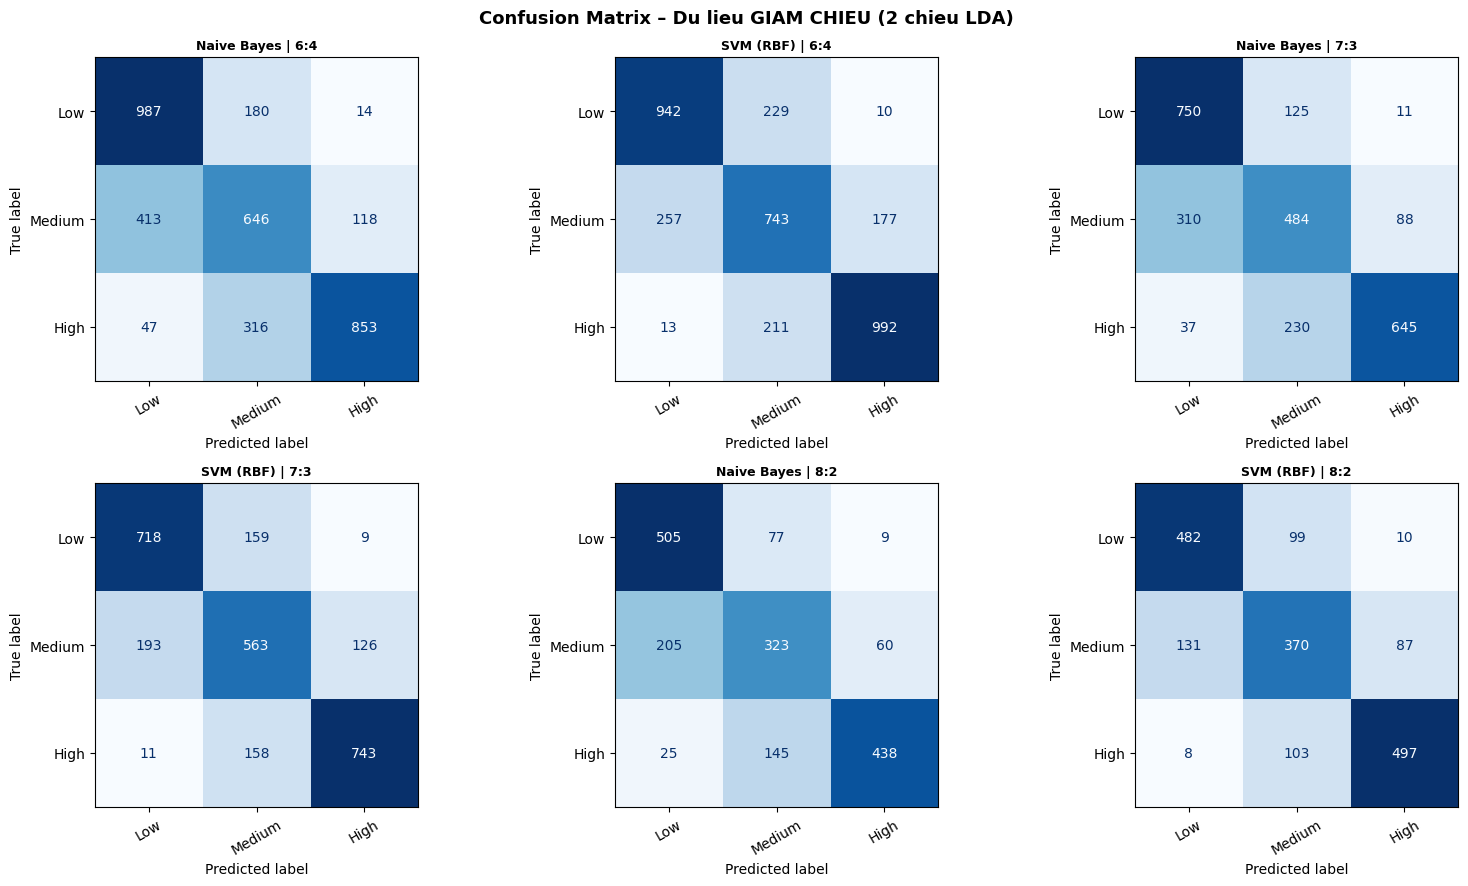

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Confusion Matrix – Du lieu GIAM CHIEU ({n_reduced} chieu LDA)',
             fontsize=13, fontweight='bold')

for idx, (yt, yp, mname, rname) in enumerate(preds_lda):
    row, col = divmod(idx, 3)
    plot_confusion(yt, yp, mname, rname, axes[row][col])

plt.tight_layout()
plt.show()

### so sanh tong hop 


In [27]:
def build_summary(results, tag):
    rows = []
    for r in results:
        rows.append({
            'Data': tag,
            'Model': r['model'],
            'Train:Test': r['ratio'],
            'Accuracy': round(r['accuracy'], 4),
            'Macro F1': round(r['report']['macro avg']['f1-score'], 4),
            'Weighted F1': round(r['report']['weighted avg']['f1-score'], 4),
        })
    return pd.DataFrame(rows)


summary = pd.concat([
    build_summary(results_orig, 'Goc (47D)'),
    build_summary(results_lda,  f'PCA ({n_reduced}D)'),
], ignore_index=True)

print(summary.to_string(index=False))


     Data       Model Train:Test  Accuracy  Macro F1  Weighted F1
Goc (47D) Naive Bayes        6:4    0.6301    0.5725       0.5743
Goc (47D)   SVM (RBF)        6:4    0.7566    0.7564       0.7573
Goc (47D) Naive Bayes        7:3    0.6340    0.5772       0.5791
Goc (47D)   SVM (RBF)        7:3    0.7739    0.7737       0.7745
Goc (47D) Naive Bayes        8:2    0.6430    0.5891       0.5910
Goc (47D)   SVM (RBF)        8:2    0.7812    0.7808       0.7816
 PCA (2D) Naive Bayes        6:4    0.6956    0.6945       0.6954
 PCA (2D)   SVM (RBF)        6:4    0.7490    0.7484       0.7494
 PCA (2D) Naive Bayes        7:3    0.7011    0.6993       0.7003
 PCA (2D)   SVM (RBF)        7:3    0.7552    0.7545       0.7554
 PCA (2D) Naive Bayes        8:2    0.7084    0.7058       0.7068
 PCA (2D)   SVM (RBF)        8:2    0.7549    0.7534       0.7543


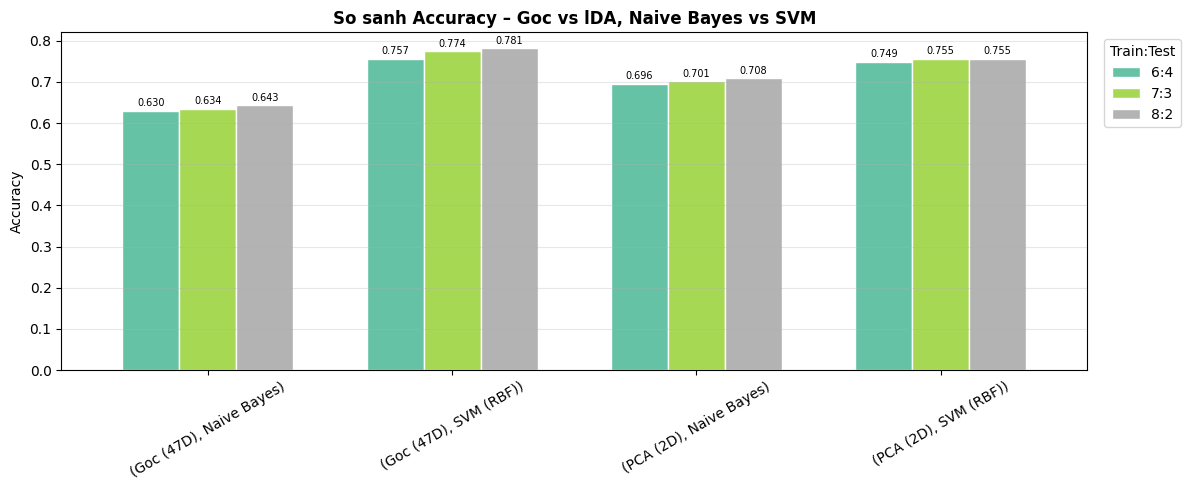

In [28]:
pivot = summary.pivot_table(
    index=['Data', 'Model'], columns='Train:Test', values='Accuracy'
)

ax = pivot.plot(kind='bar', figsize=(12, 5), rot=30,
                colormap='Set2', edgecolor='white', width=0.7)
ax.set_title('So sanh Accuracy – Goc vs lDA, Naive Bayes vs SVM', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xlabel('')
ax.legend(title='Train:Test', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()
